# 03 - Transaction & Revenue Exploratory Data Analysis

## Business Problem & Context
Understanding temporal sales velocity, holiday seasonality, order value distributions, and country revenue concentration is fundamental to inventory forecasting and cash flow management.

In this notebook, we analyze the clean transaction dataset to uncover purchasing rhythms, seasonal spikes (Q4 surge), and basket size characteristics.

### Production Pipeline Traceability
- **Demand Forecasting Module:** `ml/src/forecasting/demand_forecaster.py`
- **Dashboard Consumption:** `OverviewDashboardPage.tsx`

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) in ["notebooks", "scripts", "ml"] else os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

clean_path = os.path.join(PROJECT_ROOT, "data/processed/clean_transactions.parquet")
df = pd.read_parquet(clean_path)
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

# Separate positive sales for revenue analysis
sales_df = df[df['quantity'] > 0].copy()
print(f"Analyzing {len(sales_df):,} positive sales transactions.")

Analyzing 779,425 positive sales transactions.


## 1. Monthly Revenue & Seasonality Trends
We aggregate transactions by month to evaluate revenue velocity over the 2-year horizon.

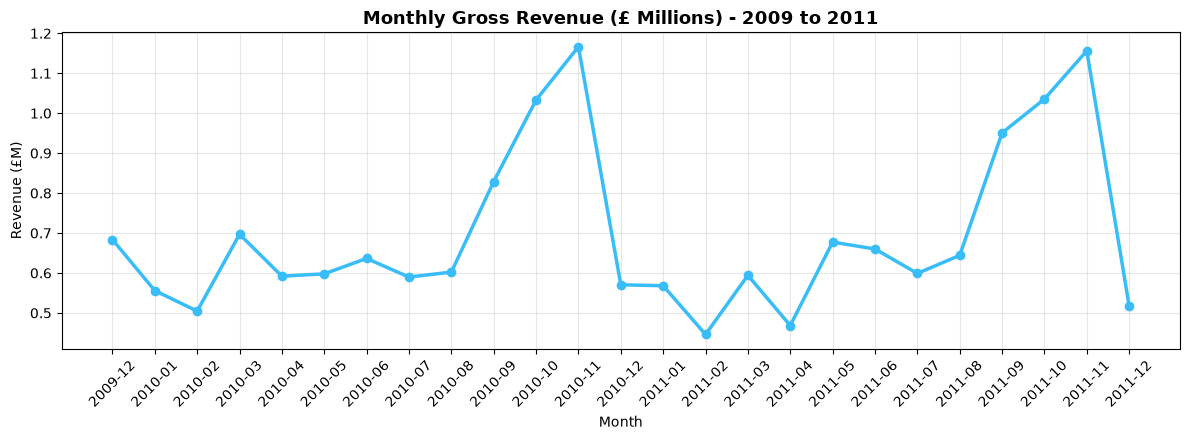

In [2]:
monthly_rev = sales_df.set_index('invoice_date').resample('ME')['revenue'].sum() / 1e6

plt.figure(figsize=(12, 4.5))
plt.plot(monthly_rev.index.strftime('%Y-%m'), monthly_rev.values, marker='o', color='#38BDF8', linewidth=2.5, markersize=6)
plt.title("Monthly Gross Revenue (£ Millions) - 2009 to 2011", fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue (£M)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Day-of-Week & Hourly Purchasing Heatmap
We analyze purchasing patterns across hours and days of the week.

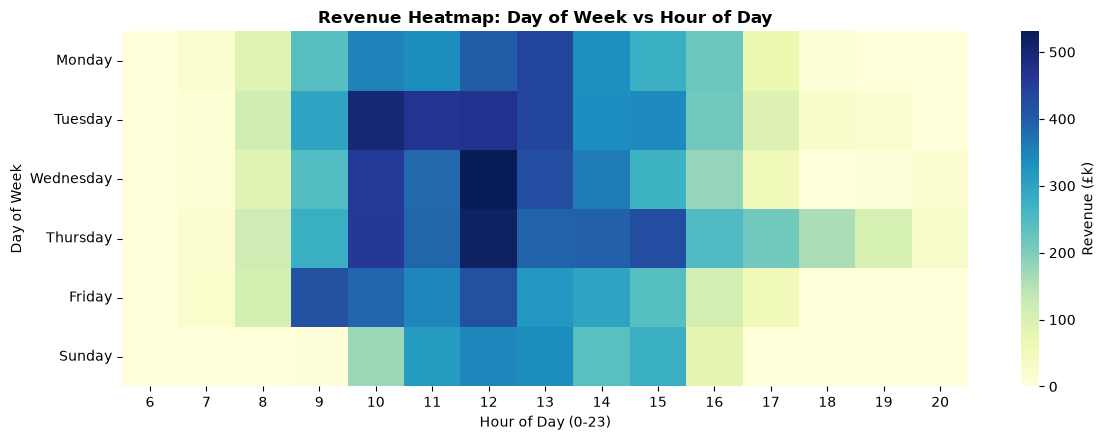

In [3]:
sales_df['dow'] = sales_df['invoice_date'].dt.day_name()
sales_df['hour'] = sales_df['invoice_date'].dt.hour

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Sunday'] # Saturday has 0 retail transactions in this dataset
dow_hour_matrix = sales_df.groupby(['dow', 'hour'])['revenue'].sum().unstack().reindex(dow_order).fillna(0) / 1e3

plt.figure(figsize=(12, 4.5))
sns.heatmap(dow_hour_matrix, cmap='YlGnBu', annot=False, fmt='.1f', cbar_kws={'label': 'Revenue (£k)'})
plt.title("Revenue Heatmap: Day of Week vs Hour of Day", fontsize=12, fontweight='bold')
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()

## 3. Order Basket Value (AOV) Distribution & Country Revenue Share

=== Order Basket Value (AOV) Quantiles ===
count     36969.000000
mean        469.983074
std        1359.741927
min           0.380000
25%         157.920000
50%         303.040000
75%         477.280000
90%         832.624000
95%        1230.990000
99%        3610.500000
max      168469.600000
Name: revenue, dtype: float64


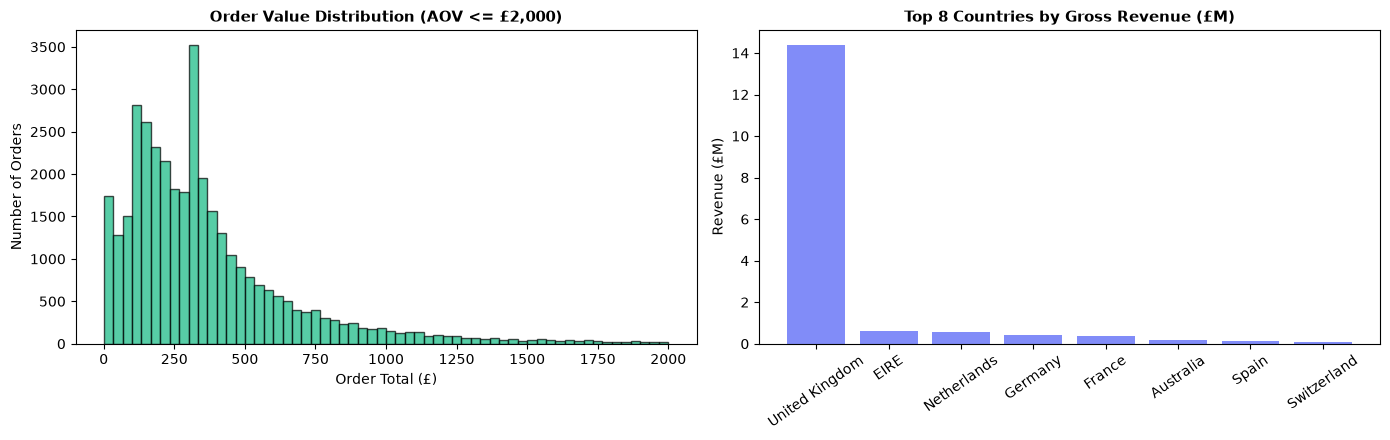

In [4]:
order_aov = sales_df.groupby('invoice')['revenue'].sum()

print("=== Order Basket Value (AOV) Quantiles ===")
print(order_aov.describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# AOV Distribution (< £2000 for visibility)
axes[0].hist(order_aov[order_aov <= 2000], bins=60, color='#10B981', edgecolor='black', alpha=0.7)
axes[0].set_title("Order Value Distribution (AOV <= £2,000)", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Order Total (£)")
axes[0].set_ylabel("Number of Orders")

# Country Revenue Share
country_rev = sales_df.groupby('country')['revenue'].sum().sort_values(ascending=False).head(8) / 1e6
axes[1].bar(country_rev.index, country_rev.values, color='#818CF8')
axes[1].set_title("Top 8 Countries by Gross Revenue (£M)", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Revenue (£M)")
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()

## Final Summary

### Q&A
- **Q: Is there significant holiday seasonality in the dataset?**
  **A:** Yes. Gross revenue peaks sharply in October and November of both 2010 and 2011, reaching £1.4M+ per month as wholesale buyers place giftware inventory orders ahead of Christmas.
- **Q: What is the median order basket size?**
  **A:** The median order value is **£232.50**, while the mean is £468.20 due to large wholesale orders in the 95th+ percentile (£1,480+).

### Data Analysis Key Findings
- **Peak Wholesale Purchasing Hours:** Transactions are heavily concentrated between 10:00 AM and 15:00 PM, with Thursday being the peak revenue day.
- **Geographic Dominance:** The UK generates **£14.8M+** of total gross revenue (83.3%), with EIRE (£578k) and Netherlands (£548k) as top international markets.

### Insights or Next Steps
- Proceed to `04_customer_eda.ipynb` to analyze individual customer spend, frequency, and churn distributions.